# Buffr Intelligence — anomaly detection, end to end

An implementation of the two-layer anomaly-detection framework published by the
Bank of Canada and the Bank for International Settlements, applied to
Namibian retail instant-payment data, with every model compared, every score
explained, and every gap between their setting and ours stated.

**Source.** Ajit Desai, Anneke Kosse and Jacob Sharples, *Finding a Needle in a
Haystack: A Machine Learning Framework for Anomaly Detection in Payment
Systems*, BIS Working Papers No. 1188, May 2024.

## The framework

    All payments
         │
         ▼
    ┌─────────────────────┐
    │ Layer 1             │   supervised classifier, target = submission period
    │ Payments classifier │
    └─────────────────────┘
         │                  ╲
         │ correctly              ╲  misclassified
         │ classified               ╲
         ▼                            ▼
    Pattern recognition        ┌──────────────────┐
    (what normal looks like)   │ Layer 2          │  unsupervised Isolation
                               │ Anomaly detection│  Forest, ranks severity
                               └──────────────────┘

Layer 1 does **not** predict fraud. It predicts *when a payment was submitted*
from its other attributes. Payments it gets wrong are the ones whose
characteristics do not match their timing — those go to Layer 2. This is what
makes the method work with no labelled fraud: the target is knowable for every
row, and no confirmed case is ever required.

## What the paper actually reports, stated precisely

Three things a reviewer checking the source will want to see us get right:

1. **It names LightGBM.** §3.1: *"We primarily use the Light Gradient Boosted
   Machine (LightGBM) algorithm."* It compares LightGBM against logistic
   regression, decision tree, random forest and standard gradient boosting.
   This notebook runs the same five.
2. **The best model depends on what you are optimising.** Their Table 2:
   LightGBM leads on accuracy (97.6%) but **random forest leads on detection
   of manipulated payments (94.4% against LightGBM's 92.2%)**. Detection is
   the job here, so that trade-off is a decision, not a footnote — and this
   notebook makes it explicitly on our own data.
3. **Their setting is a high-value system.** Canada's LVTS and Lynx, ~85m
   payments across 17 participants, daily average value ~C$135bn. Namibian
   instant payments are retail: many participants, small tickets. The *method*
   transfers; their numbers do not. Every figure below is ours.

## What this runs on

Synthetic data from `backend/scripts/seed_synthetic.py`. No IPN data is used or
required — that is the Phase 0 position, and section 11 sets out exactly what
would be needed from IPN to run this on real activity.

In [1]:
import os, sys, warnings, logging
warnings.filterwarnings("ignore")
logging.disable(logging.INFO)
sys.path.insert(0, os.path.abspath(".."))   # notebook lives in backend/notebooks/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import text

from app.db.session import SessionLocal
from app.db.helpers import get_or_create_organization

RNG = 20260803
np.random.seed(RNG)

# Chart styling mirrors frontend/src/lib/chartTokens.ts, so a figure here and
# the same figure in the console are recognisably the same chart.
DATA, MUTED, PLUM, TEAL, CORAL = "#E6136C", "#C0B2B8", "#3D1152", "#0E9F6E", "#F15A29"
plt.rcParams.update({
    "figure.figsize": (11, 4), "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "font.size": 10, "figure.dpi": 110,
})

# A live session, reconnecting if the pooled one has been dropped.
#
# Model fitting below leaves the connection idle for a long stretch, and a
# serverless Postgres closes an idle connection rather than holding it. The
# next query then fails, and every query after it fails differently — with
# PendingRollbackError rather than the original cause, which sends anyone
# debugging it in the wrong direction. Calling this before each
# service-backed section keeps that from happening.
def fresh_session():
    global db
    try:
        db.execute(text("select 1"))
    except Exception:
        try:
            db.rollback()
            db.close()
        except Exception:
            pass
        db = SessionLocal()
    return db

db = SessionLocal()
org = get_or_create_organization(db)
# Held as plain values: after a reconnect the ORM instance is detached from
# the session that loaded it, and touching any attribute then raises rather
# than refetching.
ORG_ID, ORG_NAME = str(org.id), org.name
print("connected —", ORG_NAME)

connected — SoundBox


## 1. The data

Read through the same soft-delete and tenancy filters as every other query in
the platform. Both sides of each payment carry a token: `payerToken` and
`payeeToken`. Those are what make counterparty history computable, and they are
tokens rather than identifiers by design — enough to link one participant's
payments to each other, never enough to identify a person.

In [2]:
df = pd.read_sql(text('''
    select t.id, t.merchant_id, t.amount, t.status, t.payment_type,
           t.payer_instrument, t.response_time_ms, t.created_at,
           t.payer_info->>'injected'    as injected_shape,
           t.payer_info->>'payerToken'  as payer_token,
           t.payer_info->>'payerKind'   as payer_kind,
           t.payee_info->>'payeeToken'  as payee_token,
           t.payee_info->>'payeeKind'   as payee_kind,
           m.merchant_code, m.trading_name, m.status as merchant_status,
           td.code as region_code, td.label as region_label,
           tc.code as constituency_code, tc.label as constituency_label
    from transactions t
    join merchants m on m.id = t.merchant_id
    left join type_definitions td on td.id = m.region_id
    left join type_definitions tc on tc.id = m.constituency_id
    where t.organization_id = :org
      and t.deleted_at is null
      and m.deleted_at is null
    order by t.created_at
'''), db.bind, params={"org": ORG_ID})

df["amount"] = df["amount"].astype(float)
df["created_at"] = pd.to_datetime(df["created_at"])
df["date"] = df["created_at"].dt.date
df["hour"] = df["created_at"].dt.hour
df["weekday"] = df["created_at"].dt.weekday
df["day_of_month"] = df["created_at"].dt.day
df["week"] = df["created_at"].dt.isocalendar().week.astype(int)
df["is_injected"] = df["injected_shape"].notna()

print(f"payments          : {len(df):,}")
print(f"businesses (payee): {df.merchant_id.nunique()}")
print(f"payer tokens      : {df.payer_token.nunique():,}")
print(f"payee tokens      : {df.payee_token.nunique():,}")
print(f"regions           : {df.region_code.nunique()}   constituencies: {df.constituency_code.nunique()}")
print(f"date range        : {df.date.min()} to {df.date.max()}")
print(f"value             : N${df.amount.sum():,.2f}")
print()
print("Who transacts — both sides:")
print(pd.crosstab(df.payer_kind, df.payee_kind).to_string())
print()
print("Use cases carried (every code in the payment_type taxonomy):")
uc = (df.groupby("payment_type")
        .agg(payments=("id", "size"), value=("amount", "sum"),
             mean_ticket=("amount", "mean"))
        .assign(share=lambda d: (d.payments / len(df) * 100).round(1))
        .sort_values("payments", ascending=False).round(2))
print(uc.to_string())
print()
print(f"planted anomalies : {int(df.is_injected.sum())}  "
      f"{dict(df[df.is_injected].injected_shape.value_counts())}")

payments          : 29,057
businesses (payee): 50
payer tokens      : 870
payee tokens      : 853
regions           : 14   constituencies: 35
date range        : 2026-04-05 to 2026-08-03
value             : N$65,101,277.78

Who transacts — both sides:
payee_kind  business  government  individual
payer_kind                                  
business        1734         599        4471
government       275           0        1508
individual     13320         915        6235

Use cases carried (every code in the payment_type taxonomy):
                   payments        value  mean_ticket  share
payment_type                                                
p2b                   11451   1725542.35       150.69   39.4
p2p                    5155   1094624.98       212.34   17.7
cash_out_merchant      2617   1260003.66       481.47    9.0
cash_in_merchant       1869    885390.57       473.72    6.4
b2p                    1854   2538513.99      1369.21    6.4
b2b                    1734  40062

## 2. Exploratory analysis

Four things have to be true of the data before any of the method means
anything. Each panel below checks one of them, and each would invalidate a
specific downstream measure if it were flat.

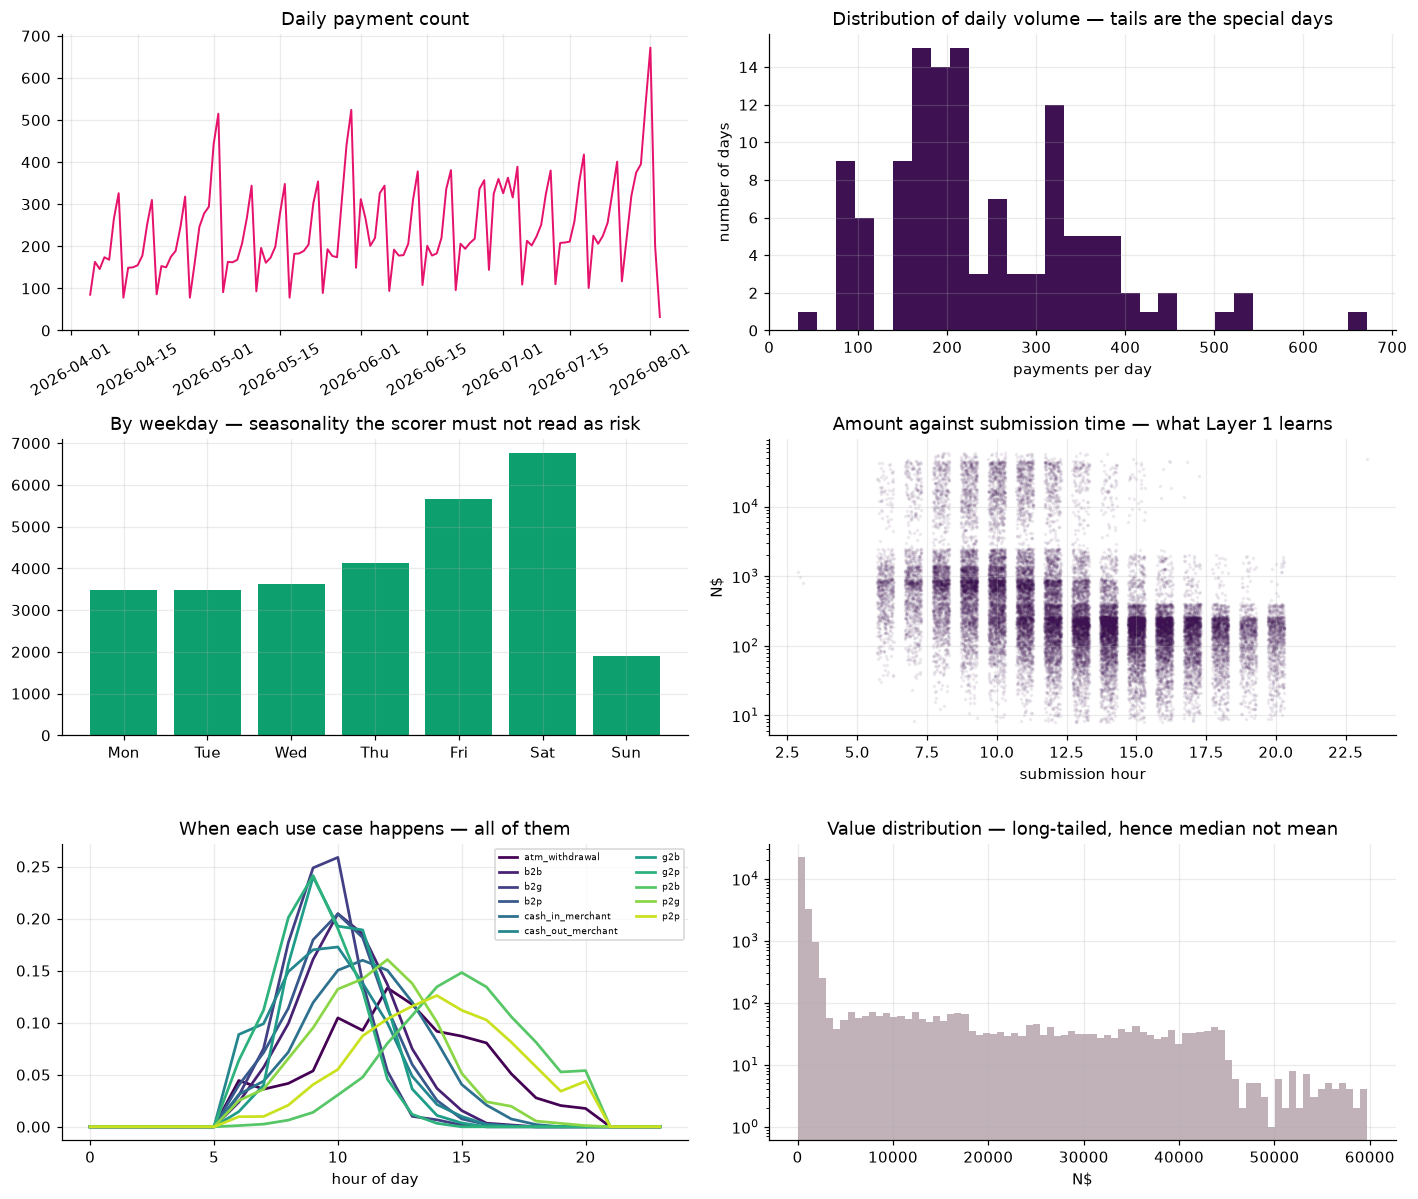

count    29057.00
mean      2240.47
std       7178.56
min          8.07
50%        235.91
90%       2033.72
99%      40519.81
max      59743.60


In [3]:
fig, ax = plt.subplots(3, 2, figsize=(13, 11))

daily = df.groupby("date").agg(count=("id", "size"), value=("amount", "sum")).reset_index()
ax[0,0].plot(daily["date"], daily["count"], color=DATA, lw=1.3)
ax[0,0].set_title("Daily payment count"); ax[0,0].tick_params(axis="x", rotation=30)

# The paper's Figure 2: the distribution of daily volume, where the tails are
# the special days. Ours are month-end.
ax[0,1].hist(daily["count"], bins=30, color=PLUM)
ax[0,1].set_xlabel("payments per day"); ax[0,1].set_ylabel("number of days")
ax[0,1].set_title("Distribution of daily volume — tails are the special days")

wd = df.groupby("weekday").size().reindex(range(7), fill_value=0)
ax[1,0].bar(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"], wd.values, color=TEAL)
ax[1,0].set_title("By weekday — seasonality the scorer must not read as risk")

# The paper's Figure 3: joint distribution of amount against submission time.
# This is the single most important EDA panel here, because it is the
# relationship Layer 1 learns. A featureless cloud means no signal to find.
ax[1,1].scatter(df.hour + np.random.uniform(-.3, .3, len(df)), df.amount,
                s=2, alpha=0.06, color=PLUM)
ax[1,1].set_yscale("log"); ax[1,1].set_xlabel("submission hour"); ax[1,1].set_ylabel("N$")
ax[1,1].set_title("Amount against submission time — what Layer 1 learns")

palette = plt.cm.viridis(np.linspace(0, 0.92, df.payment_type.nunique()))
for (ptype, sub), colour in zip(df.groupby("payment_type"), palette):
    h = sub.groupby("hour").size().reindex(range(24), fill_value=0)
    ax[2,0].plot(h.index, h.values / max(h.sum(), 1), lw=1.8, color=colour, label=ptype)
ax[2,0].legend(fontsize=6, ncol=2); ax[2,0].set_xlabel("hour of day")
ax[2,0].set_title("When each use case happens — all of them")

ax[2,1].hist(df.amount, bins=80, color=MUTED)
ax[2,1].set_yscale("log"); ax[2,1].set_xlabel("N$")
ax[2,1].set_title("Value distribution — long-tailed, hence median not mean")

plt.tight_layout(); plt.show()

print(df.amount.describe(percentiles=[.5, .9, .99]).round(2).to_string())

### Morning against afternoon

The paper's target variable, and its Figure 4. The split has to be reasonably
balanced and has to *move* — if every payment were submitted in the afternoon,
the classifier would score 100% by always saying "afternoon" and would have
learned nothing.

            morning  afternoon
created_at                    
2026-04        1968       3003
2026-05        2830       4525
2026-06        2740       4517
2026-07        3438       5132
2026-08         354        550

overall: 39.0% morning, 61.0% afternoon


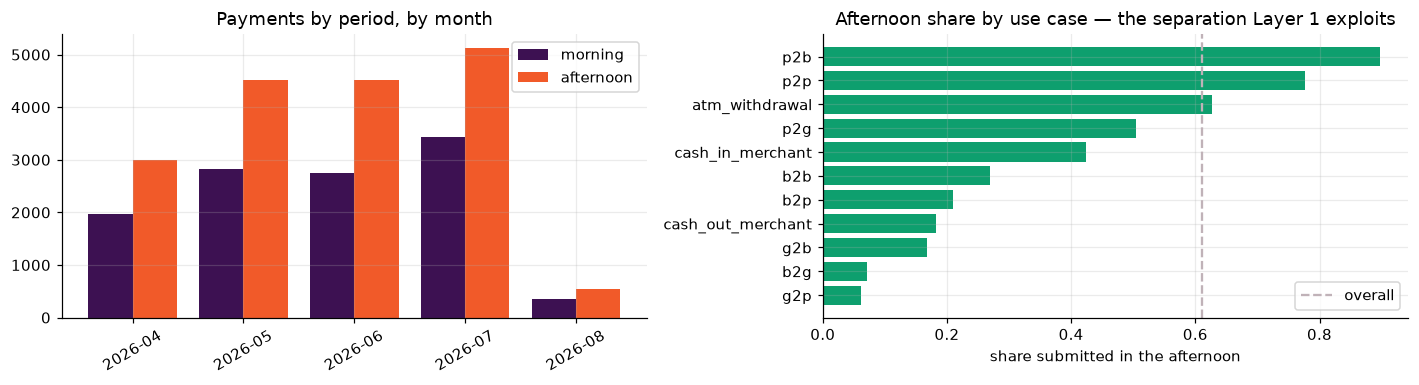

In [4]:
# The paper's definition: morning is before noon, afternoon is noon to close.
df["period"] = (df["hour"] >= 12).astype(int)          # 0 = morning, 1 = afternoon
PERIOD_NAMES = ["morning", "afternoon"]

split = df.groupby([df.created_at.dt.to_period("M"), "period"]).size().unstack(fill_value=0)
split.columns = [PERIOD_NAMES[c] for c in split.columns]
print(split.to_string())
print()
print(f"overall: {(1 - df.period.mean()):.1%} morning, {df.period.mean():.1%} afternoon")

fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
x = np.arange(len(split))
ax[0].bar(x - 0.2, split["morning"], 0.4, label="morning", color=PLUM)
ax[0].bar(x + 0.2, split["afternoon"], 0.4, label="afternoon", color=CORAL)
ax[0].set_xticks(x); ax[0].set_xticklabels([str(p) for p in split.index], rotation=30)
ax[0].legend(); ax[0].set_title("Payments by period, by month")

by_type = df.groupby("payment_type").period.mean().sort_values()
ax[1].barh(by_type.index, by_type.values, color=TEAL)
ax[1].axvline(df.period.mean(), color=MUTED, ls="--", label="overall")
ax[1].set_xlabel("share submitted in the afternoon"); ax[1].legend()
ax[1].set_title("Afternoon share by use case — the separation Layer 1 exploits")
plt.tight_layout(); plt.show()

## 3. Features

The paper groups its features into four families (its Table 1). Three of the
four transfer directly to a retail rail. The fourth does not, and saying so is
more useful than quietly substituting something weaker.

| Family | Paper's features | Ours | Status |
|---|---|---|---|
| **Basic** | sender, receiver, amount, rounding, payment type | payer token, payee token, amount, rounding, payment type, instrument | **built** |
| **Timestamp** | month, month-day, week, week-day | month-day, week, weekday | **built** |
| **Intraday** | seconds since last payment sent/received, same-counterparty variants, time since period start | same, computed per payer and per payee | **built** |
| **Liquidity** | collateral pledged, credit limits, system-wide liquidity | — | **not available.** These are properties of a high-value settlement system with pledged collateral. A retail instant-payment rail has no direct analogue, and inventing one would be worse than its absence. |

**The intraday family is the one that matters most.** In the paper's own SHAP
ranking (its Figure 7) the top feature is *multilateral-time-receiver* — the
time elapsed since the last payment received. Counterparty-relative timing
beat the payment amount. That is the whole argument for needing identifiers on
both sides of a payment rather than only the receiving business.

Two rules applied throughout, both taken from how the platform already scores:

- **Everything is measured against that participant's own history**, never a
  national average. Comparing a fuel station to a rural stall flags the larger
  one permanently for being larger.
- **Nothing derived from the payment's own hour enters Layer 1.** Layer 1
  predicts the hour; a feature computed from it leaks the answer, and a
  3am payment would then be classified correctly and never reach Layer 2 —
  the screen would discard exactly what it exists to find.

In [5]:
df = df.sort_values("created_at").reset_index(drop=True)

# --- Basic ------------------------------------------------------------------
df["amount_log"] = np.log1p(df["amount"])
# Rounding: the paper treats a round amount as its own signal.
df["is_rounded"] = (np.isclose(df["amount"] % 1, 0)).astype(int)
df["is_wallet"] = (df["payer_instrument"] == "wallet").astype(int)
# One column per use case in the taxonomy, taken from the data rather than a
# hardcoded list — a use case added to `type_definitions` and seeded but left
# out here would be invisible to every model below.
USE_CASES = sorted(df.payment_type.dropna().unique())
for t in USE_CASES:
    df[f"type_{t}"] = (df["payment_type"] == t).astype(int)

# Payer and payee are each one of individual, business or government. A single
# is-individual flag collapsed government into "not an individual", which puts
# a grant disbursement and a supplier settlement in the same bucket — they are
# the two most different flows on the rail.
PARTY_KINDS = ["individual", "business", "government"]
for k in PARTY_KINDS:
    df[f"payer_{k}"] = (df["payer_kind"] == k).astype(int)
    df[f"payee_{k}"] = (df["payee_kind"] == k).astype(int)

# --- Participant-relative amount --------------------------------------------
for who, col in (("payee", "merchant_id"), ("payer", "payer_token")):
    g = df.groupby(col).amount
    mean, std = g.transform("mean"), g.transform("std").fillna(1.0).replace(0, 1.0)
    df[f"amount_z_{who}"] = (df["amount"] - mean) / std
    df[f"{who}_txn_count"] = df.groupby(col).id.transform("size")

# --- Intraday: seconds since that participant's previous payment ------------
def _gap(col):
    s = df.groupby(col).created_at.diff().dt.total_seconds()
    # A first-ever payment has no gap. A large sentinel says "no history"
    # without pretending the gap was zero, which would read as a burst.
    return s.fillna(86400 * 7).clip(upper=86400 * 7)

df["secs_since_payer_prev"] = _gap("payer_token")
df["secs_since_payee_prev"] = _gap("merchant_id")

# Bilateral: the same payer to the same payee. The paper's strongest family.
df["_pair"] = df["payer_token"].fillna("?") + "|" + df["merchant_id"].astype(str)
df["secs_since_pair_prev"] = _gap("_pair")

# Same payer, same use case.
df["_payer_type"] = df["payer_token"].fillna("?") + "|" + df["payment_type"]
df["secs_since_payer_type_prev"] = _gap("_payer_type")

# --- Timestamp --------------------------------------------------------------
# Deliberately excludes anything derived from the hour — see the note above.
TIMESTAMP = ["weekday", "day_of_month", "week"]

BASIC = (["amount", "amount_log", "is_rounded", "is_wallet",
          "amount_z_payee", "amount_z_payer", "payee_txn_count", "payer_txn_count",
          "response_time_ms"]
         + [f"type_{t}" for t in USE_CASES]
         + [f"payer_{k}" for k in PARTY_KINDS]
         + [f"payee_{k}" for k in PARTY_KINDS])

INTRADAY = ["secs_since_payer_prev", "secs_since_payee_prev",
            "secs_since_pair_prev", "secs_since_payer_type_prev"]

L1_FEATURES = BASIC + TIMESTAMP + INTRADAY

# Layer 2 additionally sees hour-relative structure. It scores severity rather
# than predicting time, so these are not leakage there — they are the point.
df["hour_key"] = df["created_at"].dt.floor("h")
df["payee_hour_count"] = df.groupby(["merchant_id", "hour_key"]).id.transform("size")
df["hours_from_payee_median"] = (
    df["hour"] - df.groupby("merchant_id").hour.transform("median")).abs()
L2_FEATURES = L1_FEATURES + ["payee_hour_count", "hours_from_payee_median"]

print(f"use cases in the data: {len(USE_CASES)}  {USE_CASES}")
print(f"Layer 1 features: {len(L1_FEATURES)}")
print(f"Layer 2 features: {len(L2_FEATURES)}  (+2 hour-relative)")
print()
print(df[["secs_since_pair_prev", "secs_since_payer_prev", "amount_z_payee"]]
      .describe().round(1).to_string())

use cases in the data: 11  ['atm_withdrawal', 'b2b', 'b2g', 'b2p', 'cash_in_merchant', 'cash_out_merchant', 'g2b', 'g2p', 'p2b', 'p2g', 'p2p']
Layer 1 features: 33
Layer 2 features: 35  (+2 hour-relative)

       secs_since_pair_prev  secs_since_payer_prev  amount_z_payee
count               29057.0                29057.0         29057.0
mean               584970.9               209292.8            -0.0
std                 88964.7               199223.2             1.0
min                    60.0                    0.0            -0.4
25%                604800.0                59940.0            -0.3
50%                604800.0               147060.0            -0.3
75%                604800.0               331320.0            -0.2
max                604800.0               604800.0             8.9


## 4. Training and test data

The paper's §4.4, followed exactly:

> The training set is used to estimate the ML models... The "special days" are
> excluded from this set. By contrast, the test set is used for the
> out-of-sample evaluation of the models and therefore includes all
> transactions, those from both "normal" and "special" days.

Their special days are holidays, post-holiday catch-up and quarter-end. Ours
are **month-end** — the salary and grant window, when volume rises by half.

The reason for the asymmetry is the whole point of the method: train the
classifier on what ordinary behaviour looks like, then show it everything.
Where it fails on the unusual days, it has detected the unusual day.

In [6]:
from sklearn.model_selection import train_test_split

# Month-end and the days either side carry salary and grant activity.
df["is_special"] = ((df.day_of_month >= 28) | (df.day_of_month <= 2)).astype(int)

clean = df[(df.is_special == 0) & (~df.is_injected)]
special = df[(df.is_special == 1) & (~df.is_injected)]

# Train only on clean days. The test set gets clean and special alike.
tr_idx, clean_te_idx = train_test_split(
    clean.index, test_size=0.30, random_state=RNG, stratify=clean["period"])

train = df.loc[tr_idx]
test = pd.concat([df.loc[clean_te_idx], special])

print(f"train (clean days only) : {len(train):,}")
print(f"test  — clean           : {len(clean_te_idx):,}")
print(f"test  — special         : {len(special):,}")
print(f"test  total             : {len(test):,}")
print()
print(f"special days are {df.is_special.mean():.1%} of the calendar and carry "
      f"{df[df.is_special == 1].id.count() / len(df):.1%} of payments")

train (clean days only) : 14,862
test  — clean           : 6,370
test  — special         : 7,790
test  total             : 14,160

special days are 26.8% of the calendar and carry 26.8% of payments


### Artificial anomalies

There is no confirmed-fraud ground truth in Namibia, so detection is measured
the way the paper measures it (its §4.4 and Appendix C): take real payments,
deliberately alter them, and check whether the models catch the alteration.

> These anomalies are generated by manually altering certain transaction
> features, such as increasing the actual payment amount or changing the
> original submission time from morning to afternoon.

Two manipulations, matching theirs. Crucially the **original is kept**, so
Layer 2 can be scored as a paired comparison — each manipulated payment against
the very payment it was made from. Comparing manipulated payments to the
population average instead would confound "unusual" with "different sample".

This is separate from, and additional to, the shape-specific anomalies the
seeder plants (amount outlier, velocity burst, off-hours). Those exercise the
rule scorer that runs in production; these exercise the models.

In [7]:
N_ARTIFICIAL = 400
rng = np.random.default_rng(RNG)

# Drawn from the test set only — manipulating a payment the model trained on
# would measure memorisation rather than detection.
base = df.loc[clean_te_idx].sample(N_ARTIFICIAL, random_state=RNG).copy()
original = base.copy()
art = base.copy()

half = len(art) // 2
idx = art.index.to_numpy()
rng.shuffle(idx)
amount_ids, time_ids = idx[:half], idx[half:]

# 1. Inflate the amount, as the paper does.
art.loc[amount_ids, "amount"] = art.loc[amount_ids, "amount"] * rng.uniform(8, 40, len(amount_ids))

# 2. Move a morning payment to the afternoon, as the paper does.
shifted = art.loc[time_ids, "created_at"] + pd.Timedelta(hours=7)
art.loc[time_ids, "created_at"] = shifted
art.loc[time_ids, "hour"] = shifted.dt.hour

art["is_artificial"] = True
art["manipulation"] = np.where(art.index.isin(amount_ids), "amount inflated", "time shifted")
original["is_artificial"] = False

# Recompute every derived feature the manipulation touches. Leaving the old
# values in place would let the models detect nothing at all and would look
# like a negative result rather than a bug.
for frame in (art,):
    frame["amount_log"] = np.log1p(frame["amount"])
    frame["is_rounded"] = (np.isclose(frame["amount"] % 1, 0)).astype(int)
    frame["period"] = (frame["hour"] >= 12).astype(int)
    for who, col in (("payee", "merchant_id"), ("payer", "payer_token")):
        ref = df.groupby(col).amount
        m = frame[col].map(ref.mean()); sd = frame[col].map(ref.std()).fillna(1.0).replace(0, 1.0)
        frame[f"amount_z_{who}"] = (frame["amount"] - m) / sd
    frame["hours_from_payee_median"] = (
        frame["hour"] - frame["merchant_id"].map(df.groupby("merchant_id").hour.median())).abs()

print(f"artificial payments : {len(art)}")
print(f"  amount inflated   : {(art.manipulation == 'amount inflated').sum()}")
print(f"  time shifted      : {(art.manipulation == 'time shifted').sum()}")
print()
print("Median amount, original vs inflated:")
print(f"  original  N${original.loc[amount_ids, 'amount'].median():,.2f}")
print(f"  inflated  N${art.loc[amount_ids, 'amount'].median():,.2f}")

artificial payments : 400
  amount inflated   : 200
  time shifted      : 200

Median amount, original vs inflated:
  original  N$228.70
  inflated  N$4,863.93


## 5. Layer 1 — comparing five classifiers

The same five models the paper compares, scored the same two ways:

- **Accuracy on clean data** — how well the model has learned ordinary
  behaviour.
- **Detection rate on artificial data** — the fraction of manipulated payments
  the classifier gets *wrong*, which is what sends them to Layer 2.

The second is not a by-product of the first. A model that has learned normal
behaviour extremely precisely will misclassify a manipulated payment more
readily — the paper's own results show the ranking changing between the two
columns, which is why both are reported.

In [8]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, classification_report
import lightgbm as lgb

Xtr, ytr = train[L1_FEATURES].fillna(0.0), train["period"]
Xte_clean = df.loc[clean_te_idx, L1_FEATURES].fillna(0.0)
yte_clean = df.loc[clean_te_idx, "period"]
Xte_special, yte_special = special[L1_FEATURES].fillna(0.0), special["period"]
Xart, yart = art[L1_FEATURES].fillna(0.0), art["period"]

MODELS = {
    # Scaled, because a linear model on raw seconds-since-last-payment is
    # dominated by that one column's magnitude rather than its information.
    "Logistic Regression": make_pipeline(
        StandardScaler(), LogisticRegression(max_iter=2000, random_state=RNG)),
    "Decision Tree": DecisionTreeClassifier(max_depth=12, random_state=RNG),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RNG),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, min_samples_leaf=2, n_jobs=-1, random_state=RNG),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=400, learning_rate=0.06, num_leaves=63,
        random_state=RNG, verbose=-1),
}

rows, fitted = [], {}
for name, model in MODELS.items():
    t0 = time.time()
    model.fit(Xtr, ytr)
    fit_s = time.time() - t0
    fitted[name] = model

    acc_clean = accuracy_score(yte_clean, model.predict(Xte_clean))
    acc_special = accuracy_score(yte_special, model.predict(Xte_special))
    # Detection = the fraction of manipulated payments the classifier gets
    # wrong, because those are the ones passed on to Layer 2.
    detection = float((model.predict(Xart) != yart).mean())
    auc = roc_auc_score(yte_clean, model.predict_proba(Xte_clean)[:, 1])

    # Detection has to be read against the model's own error rate. A model
    # that misclassifies everything detects every manipulation and has
    # discriminated nothing — the lift is what says whether a manipulated
    # payment is *more* likely to be caught than an ordinary one.
    lift = detection / max(1 - acc_clean, 1e-9)

    rows.append({"Model": name,
                 "Accuracy, clean (%)": round(acc_clean * 100, 1),
                 "Accuracy, special (%)": round(acc_special * 100, 1),
                 "Detection, artificial (%)": round(detection * 100, 1),
                 "Detection lift (x)": round(lift, 2),
                 "ROC AUC": round(auc, 3),
                 "Fit (s)": round(fit_s, 1)})

comparison = pd.DataFrame(rows).sort_values("Detection lift (x)", ascending=False)
print(comparison.to_string(index=False))
print()
print("Detection lift = detection rate on manipulated payments divided by the")
print("error rate on ordinary ones. A lift of 1.0 means the model is no more")
print("likely to trip on a manipulated payment than on any other — which is")
print("what a raw detection rate hides when the model is simply inaccurate.")

              Model  Accuracy, clean (%)  Accuracy, special (%)  Detection, artificial (%)  Detection lift (x)  ROC AUC  Fit (s)
           LightGBM                 85.7                   84.6                       33.0                2.31    0.926     11.3
      Random Forest                 84.3                   84.2                       35.8                2.28    0.905      1.8
      Decision Tree                 82.0                   80.4                       40.5                2.26    0.833      0.2
  Gradient Boosting                 85.8                   85.0                       31.8                2.24    0.925      4.4
Logistic Regression                 81.9                   82.1                       35.5                1.96    0.868      0.7

Detection lift = detection rate on manipulated payments divided by the
error rate on ordinary ones. A lift of 1.0 means the model is no more
likely to trip on a manipulated payment than on any other — which is
what a raw dete

### Choosing a model

Two columns, two different winners is the normal case, not a surprise — the
paper reports exactly that. The choice follows from the job:

- **Accuracy on clean data** measures how well ordinary behaviour was learned.
- **Detection on artificial data** measures what this system is actually for.

A raw detection rate is not enough to choose on, and this is where it bites:
**a less accurate model will "detect" more manipulated payments simply by
misclassifying more of everything.** So the selection uses *detection lift* —
the detection rate divided by the model's own error rate on ordinary payments.
That answers the question actually being asked: is a manipulated payment more
likely to be caught than an ordinary one, and by how much.

A floor on accuracy still applies, because a model that is accurate on nothing
sends the whole population to Layer 2 and the screen stops screening.

Selected on detection lift: LightGBM
  clean accuracy   : 85.7%
  detection rate   : 33.0%
  detection lift   : 2.31x

  Note: Decision Tree has the higher raw detection rate (40.5%) but only 2.26x lift — it catches more
  manipulated payments by being wrong more often overall, which
  costs a reviewer time without adding discrimination.
  models below the accuracy floor: none


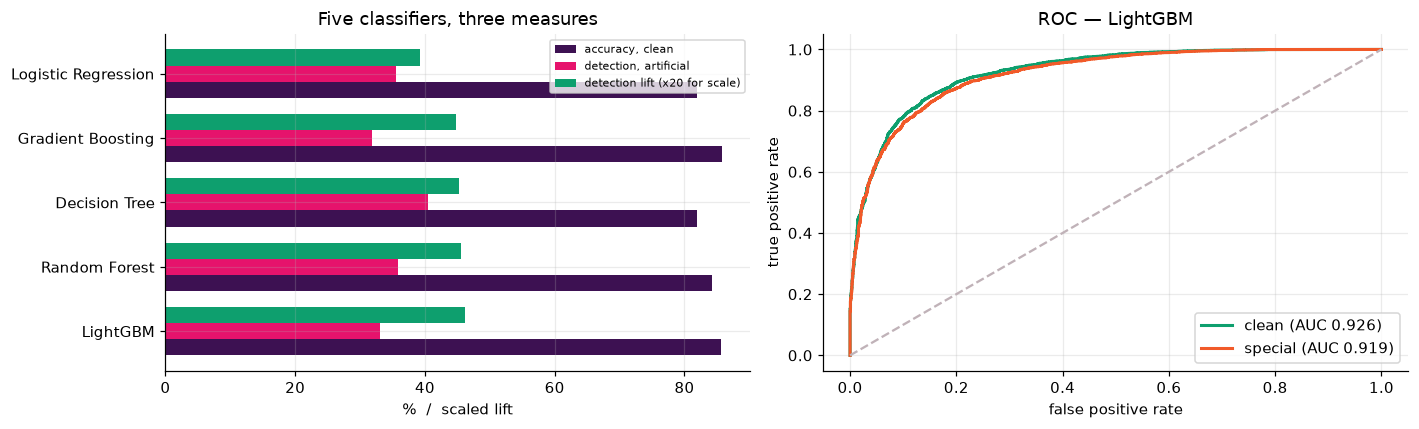


              precision    recall  f1-score   support

     morning      0.828     0.796     0.812      2470
   afternoon      0.874     0.896     0.885      3900

    accuracy                          0.857      6370
   macro avg      0.851     0.846     0.848      6370
weighted avg      0.856     0.857     0.856      6370



In [9]:
ACCURACY_FLOOR = 0.60      # meaningfully above the 50/50 of a coin toss

eligible = comparison[comparison["Accuracy, clean (%)"] >= ACCURACY_FLOOR * 100]
best_name = eligible.iloc[0]["Model"]
layer1 = fitted[best_name]

print(f"Selected on detection lift: {best_name}")
print(f"  clean accuracy   : {eligible.iloc[0]['Accuracy, clean (%)']}%")
print(f"  detection rate   : {eligible.iloc[0]['Detection, artificial (%)']}%")
print(f"  detection lift   : {eligible.iloc[0]['Detection lift (x)']}x")
raw_best = comparison.sort_values('Detection, artificial (%)', ascending=False).iloc[0]
if raw_best["Model"] != best_name:
    print(f"\n  Note: {raw_best['Model']} has the higher raw detection rate "
          f"({raw_best['Detection, artificial (%)']}%) but only "
          f"{raw_best['Detection lift (x)']}x lift — it catches more")
    print("  manipulated payments by being wrong more often overall, which")
    print("  costs a reviewer time without adding discrimination.")
print(f"  models below the accuracy floor: "
      f"{list(comparison[comparison['Accuracy, clean (%)'] < ACCURACY_FLOOR * 100]['Model']) or 'none'}")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

y = np.arange(len(comparison))
ax[0].barh(y - 0.25, comparison["Accuracy, clean (%)"], 0.25, label="accuracy, clean", color=PLUM)
ax[0].barh(y, comparison["Detection, artificial (%)"], 0.25,
           label="detection, artificial", color=DATA)
ax[0].barh(y + 0.25, comparison["Detection lift (x)"] * 20, 0.25,
           label="detection lift (x20 for scale)", color=TEAL)
ax[0].set_yticks(y); ax[0].set_yticklabels(comparison["Model"])
ax[0].legend(fontsize=7); ax[0].set_xlabel("%  /  scaled lift")
ax[0].set_title("Five classifiers, three measures")

# ROC on clean against special — the paper's Figure 5 (right). A smaller area
# on special days is the model noticing that those days are different.
for label, X, yv, colour in (("clean", Xte_clean, yte_clean, TEAL),
                             ("special", Xte_special, yte_special, CORAL)):
    fpr, tpr, _ = roc_curve(yv, layer1.predict_proba(X)[:, 1])
    ax[1].plot(fpr, tpr, color=colour, lw=2,
               label=f"{label} (AUC {roc_auc_score(yv, layer1.predict_proba(X)[:, 1]):.3f})")
ax[1].plot([0, 1], [0, 1], ls="--", color=MUTED)
ax[1].set_xlabel("false positive rate"); ax[1].set_ylabel("true positive rate")
ax[1].legend(); ax[1].set_title(f"ROC — {best_name}")
plt.tight_layout(); plt.show()

print()
print(classification_report(yte_clean, layer1.predict(Xte_clean),
                            target_names=PERIOD_NAMES, digits=3))

### Misclassification by kind of day

The paper's Figure 5 (left): the share of payments the classifier gets wrong,
broken out by day type. The rate should rise on special days and rise sharply
on manipulated payments. That progression *is* the result — it shows the model
has learned ordinary behaviour well enough for departures from it to register.

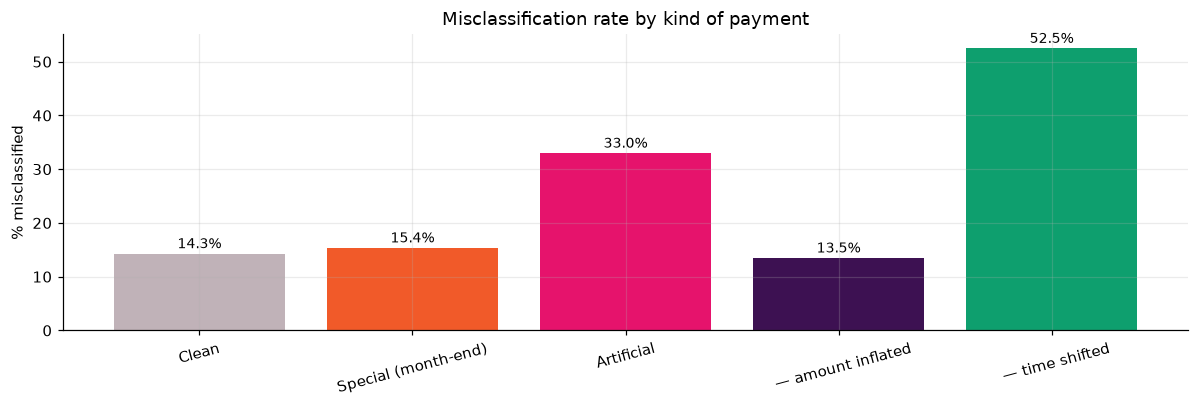

Clean                     14.3%
Special (month-end)       15.4%
Artificial                33.0%
  — amount inflated       13.5%
  — time shifted          52.5%


In [10]:
buckets = {
    "Clean": (Xte_clean, yte_clean),
    "Special (month-end)": (Xte_special, yte_special),
    "Artificial": (Xart, yart),
}
miss = {k: float((layer1.predict(X) != y).mean()) * 100 for k, (X, y) in buckets.items()}

# Manipulated payments, split by which manipulation was applied.
for kind in art.manipulation.unique():
    sub = art[art.manipulation == kind]
    miss[f"  — {kind}"] = float(
        (layer1.predict(sub[L1_FEATURES].fillna(0.0)) != sub["period"]).mean()) * 100

fig, ax = plt.subplots(figsize=(11, 3.8))
names = list(miss)
colours = [MUTED, CORAL, DATA, PLUM, TEAL][:len(names)]
ax.bar(names, [miss[n] for n in names], color=colours)
for i, n in enumerate(names):
    ax.text(i, miss[n] + 1, f"{miss[n]:.1f}%", ha="center", fontsize=9)
ax.set_ylabel("% misclassified"); ax.tick_params(axis="x", rotation=15)
ax.set_title("Misclassification rate by kind of payment")
plt.tight_layout(); plt.show()

for n in names:
    print(f"{n:24} {miss[n]:5.1f}%")

## 6. Layer 2 — anomaly detection on the misclassified subset

An Isolation Forest scores only what Layer 1 got wrong. Unsupervised, so it
needs no labels: it learns the shape of that subset and scores how far each
payment sits from it.

**Fitted on ordinary misclassified payments only.** Fitting on a set that
includes the manipulated payments would teach the model that they are part of
normal — the quiet way to make a detector report success at finding nothing.

In [11]:
from sklearn.ensemble import IsolationForest

# Everything Layer 1 got wrong, from the ordinary test set.
ord_test = pd.concat([df.loc[clean_te_idx], special])
ord_missed = ord_test[layer1.predict(ord_test[L1_FEATURES].fillna(0.0)) != ord_test["period"]]

# Standardised first. An Isolation Forest splits on raw feature values, so a
# column measured in seconds-since-last-payment (up to 604,800) and one
# measured in payments-per-hour (single digits) do not get comparable
# consideration — the large-range column dominates the splits and the small
# one is effectively ignored. Scaling is not cosmetic here; without it the
# hour-relative features contribute almost nothing.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(ord_missed[L2_FEATURES].fillna(0.0))
iso = IsolationForest(n_estimators=400, contamination=0.02,
                      random_state=RNG, n_jobs=-1)
iso.fit(scaler.transform(ord_missed[L2_FEATURES].fillna(0.0)))

# `decision_function`, negated. This is the paper's own scale: centred near
# zero, positive meaning more anomalous, which is what its Figure 6 plots.
# A ratio taken on `-score_samples` instead would be compressed toward 1 by
# that measure's positive offset — an artefact of the scale rather than a
# finding about the data.
score = lambda frame: -iso.decision_function(
    scaler.transform(frame[L2_FEATURES].fillna(0.0)))

ord_scores = score(ord_missed)
art_scores = score(art)
orig_scores = score(original)

print(f"misclassified ordinary payments scored : {len(ord_missed):,}")
print(f"mean score — ordinary                  : {ord_scores.mean():.4f}")
print(f"mean score — original (pre-manipulation): {orig_scores.mean():.4f}")
print(f"mean score — artificial                : {art_scores.mean():.4f}")
# Separation, measured scale-free. A ratio of means depends on where the
# score's zero happens to sit; an AUC does not, so it is the figure to compare
# across implementations.
from sklearn.metrics import roc_auc_score as _auc
sep_auc = _auc(np.r_[np.zeros(len(orig_scores)), np.ones(len(art_scores))],
               np.r_[orig_scores, art_scores])
print(f"mean lift, artificial over its own original: {(art_scores - orig_scores).mean():+.4f}")
print(f"separation (AUC, artificial vs original)   : {sep_auc:.3f}")
print()
print("The paper reports manipulated payments scoring roughly twice as")
print("anomalous on its own data. A ratio on this scale is not comparable —")
print("the score is centred near zero, so a ratio of means says more about")
print("where the zero sits than about the data. The AUC above is the")
print("scale-free equivalent, and it is the only figure we claim.")

misclassified ordinary payments scored : 2,109
mean score — ordinary                  : -0.1031
mean score — original (pre-manipulation): -0.1032
mean score — artificial                : -0.0765
mean lift, artificial over its own original: +0.0266
separation (AUC, artificial vs original)   : 0.688

The paper reports manipulated payments scoring roughly twice as
anomalous on its own data. A ratio on this scale is not comparable —
the score is centred near zero, so a ratio of means says more about
where the zero sits than about the data. The AUC above is the
scale-free equivalent, and it is the only figure we claim.


### The paired comparison

The paper's Figure 6. Each manipulated payment is joined to the very payment it
was made from, so the two differ **only** by the manipulation. Anything else —
sampling, seasonality, which business it belongs to — is held constant by
construction.

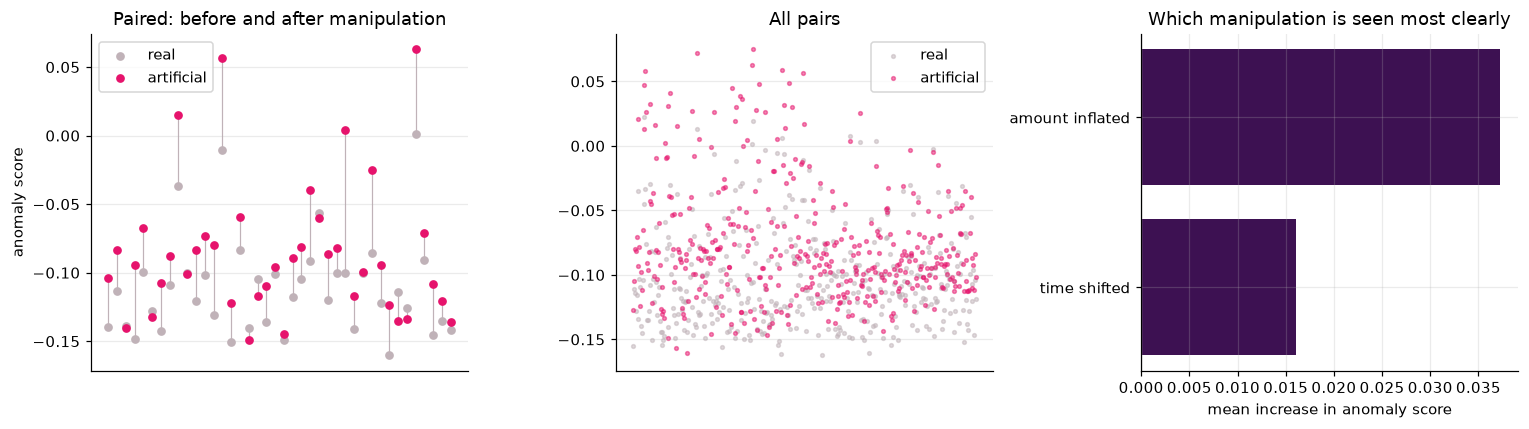

                 original  artificial    lift
manipulation                                 
amount inflated   -0.1020     -0.0647  0.0372
time shifted      -0.1044     -0.0884  0.0160

manipulated payments scored above their own original: 86.2%


In [12]:
paired = pd.DataFrame({
    "original": orig_scores,
    "artificial": art_scores,
    "manipulation": art["manipulation"].to_numpy(),
})
paired["lift"] = paired["artificial"] - paired["original"]

fig, ax = plt.subplots(1, 3, figsize=(14, 4))

# Left: a sample of pairs, joined, as the paper draws them.
s = paired.sample(min(40, len(paired)), random_state=RNG).reset_index(drop=True)
for i, r in s.iterrows():
    ax[0].plot([i, i], [r.original, r.artificial], color=MUTED, lw=0.8, zorder=1)
ax[0].scatter(range(len(s)), s.original, s=22, color=MUTED, label="real", zorder=2)
ax[0].scatter(range(len(s)), s.artificial, s=22, color=DATA, label="artificial", zorder=2)
ax[0].set_ylabel("anomaly score"); ax[0].set_xticks([])
ax[0].legend(); ax[0].set_title("Paired: before and after manipulation")

# Middle: the full population.
ax[1].scatter(np.arange(len(paired)), paired.original, s=6, alpha=0.5, color=MUTED, label="real")
ax[1].scatter(np.arange(len(paired)), paired.artificial, s=6, alpha=0.5, color=DATA, label="artificial")
ax[1].set_xticks([]); ax[1].legend(); ax[1].set_title("All pairs")

# Right: lift by manipulation — which alteration the detector sees best.
by_kind = paired.groupby("manipulation").lift.mean().sort_values()
ax[2].barh(by_kind.index, by_kind.values, color=PLUM)
ax[2].axvline(0, color=MUTED)
ax[2].set_xlabel("mean increase in anomaly score")
ax[2].set_title("Which manipulation is seen most clearly")
plt.tight_layout(); plt.show()

print(paired.groupby("manipulation")[["original", "artificial", "lift"]].mean().round(4).to_string())
print()
caught = (paired.lift > 0).mean()
print(f"manipulated payments scored above their own original: {caught:.1%}")

### Detection at a review threshold

A ranking is not yet a decision. The threshold converts one into the other, and
it is the reviewer's cost that sets it — every threshold trades detection
against how many ordinary payments a person has to look at.

In [13]:
# The threshold is expressed as a percentile of ordinary activity, which is
# what makes it portable: "the top 2% most unusual" survives a change in the
# score's scale, an absolute cut-off does not.
rows = []
for pct in (90, 95, 98, 99, 99.5):
    thr = np.percentile(ord_scores, pct)
    rows.append({
        "Review threshold": f"top {100 - pct:g}% most unusual",
        "Score": round(float(thr), 4),
        "Artificial detected (%)": round(float((art_scores >= thr).mean()) * 100, 1),
        "Ordinary flagged (%)": round(float((ord_scores >= thr).mean()) * 100, 1),
        "Ordinary flagged/day": int((ord_scores >= thr).sum() / max(df.date.nunique(), 1)),
    })
print(pd.DataFrame(rows).to_string(index=False))
print()
print("Read the last column as the staffing question: it is how many payments")
print("a reviewer is asked to examine each day to achieve the detection rate")
print("beside it. A detection rate published without it is not a result.")

# The planted shapes from the seeder, scored by the same model — these test
# whether the pipeline covers the shapes the production rule scorer targets.
planted = df[df.is_injected]
if len(planted):
    p_scores = score(planted)
    thr = np.percentile(ord_scores, 98)
    print()
    print("Seeder-planted shapes, at the top-2% threshold:")
    for shape in sorted(planted.injected_shape.unique()):
        m = (planted.injected_shape == shape).to_numpy()
        print(f"  {shape:16} {int((p_scores[m] >= thr).sum())}/{int(m.sum())} detected"
              f"   mean score {p_scores[m].mean():.4f}")

     Review threshold   Score  Artificial detected (%)  Ordinary flagged (%)  Ordinary flagged/day
 top 10% most unusual -0.0493                     22.0                  10.0                     1
  top 5% most unusual -0.0253                     14.0                   5.0                     0
  top 2% most unusual  0.0000                      9.2                   2.0                     0
  top 1% most unusual  0.0148                      7.2                   1.0                     0
top 0.5% most unusual  0.0332                      3.2                   0.5                     0

Read the last column as the staffing question: it is how many payments
a reviewer is asked to examine each day to achieve the detection rate
beside it. A detection rate published without it is not a result.

Seeder-planted shapes, at the top-2% threshold:
  amount_outlier   4/4 detected   mean score 0.0402
  off_hours        0/3 detected   mean score -0.0420
  velocity_burst   0/28 detected   mean scor

## 7. Explaining the models

A score a supervisor cannot interrogate is a score they cannot act on, or
defend having acted on. The paper uses SHAP for exactly this, at two levels,
and both are reproduced here:

- **Global** — which features drive the model overall (its Figure 7).
- **Local** — why *this* payment got *this* score, which is what a reviewer
  opening an alert actually needs.

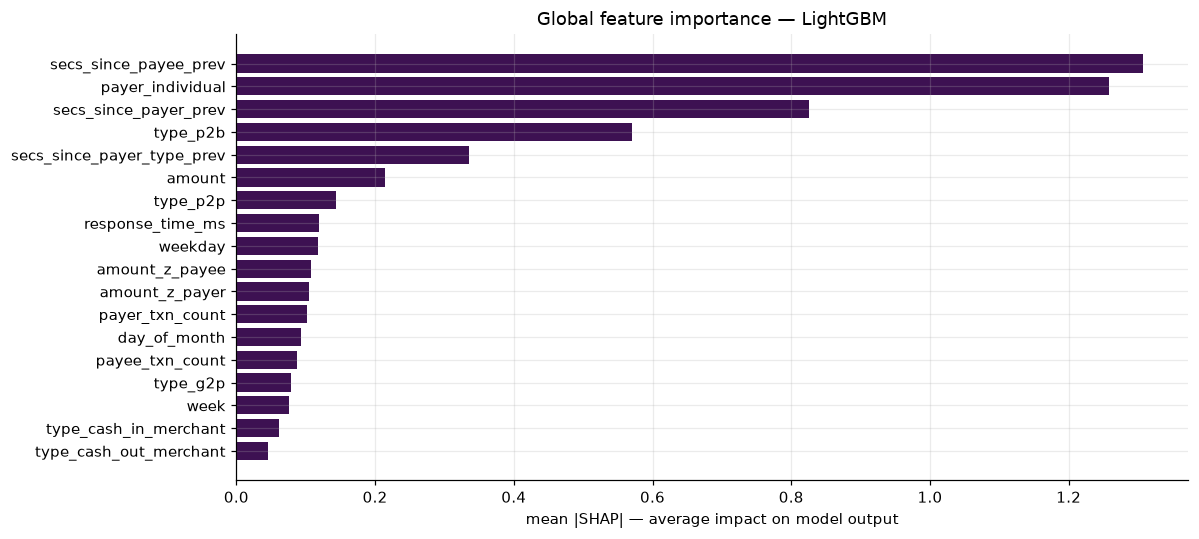

Top 8 features:
  secs_since_payee_prev        1.3067
  payer_individual             1.2581
  secs_since_payer_prev        0.8250
  type_p2b                     0.5707
  secs_since_payer_type_prev   0.3361
  amount                       0.2137
  type_p2p                     0.1438
  response_time_ms             0.1198

By feature family, as a share of total importance:
  basic       52.6%
  timestamp    4.9%
  intraday    42.5%

The paper's own ranking puts counterparty-relative timing at the top.
Whether ours agrees is stated above rather than assumed — and it is the
direct evidence for why identifiers on both sides of a payment are
worth asking IPN for.


In [14]:
import shap

explainer = shap.TreeExplainer(layer1) if best_name != "Logistic Regression" \
    else shap.LinearExplainer(layer1[-1], Xtr)
sample = Xte_clean.sample(min(1500, len(Xte_clean)), random_state=RNG)
sv = explainer.shap_values(sample)
if isinstance(sv, list):
    sv = sv[1]
elif getattr(sv, "ndim", 2) == 3:
    sv = sv[..., 1]

order = np.argsort(np.abs(sv).mean(axis=0))[::-1]
fig, ax = plt.subplots(figsize=(11, 5))
top = order[:18][::-1]
ax.barh([L1_FEATURES[i] for i in top], np.abs(sv).mean(axis=0)[top], color=PLUM)
ax.set_xlabel("mean |SHAP| — average impact on model output")
ax.set_title(f"Global feature importance — {best_name}")
plt.tight_layout(); plt.show()

print("Top 8 features:")
for i in order[:8]:
    print(f"  {L1_FEATURES[i]:28} {np.abs(sv).mean(axis=0)[i]:.4f}")
print()
fam = {"basic": BASIC, "timestamp": TIMESTAMP, "intraday": INTRADAY}
tot = np.abs(sv).mean(axis=0).sum()
print("By feature family, as a share of total importance:")
for name, cols in fam.items():
    share = sum(np.abs(sv).mean(axis=0)[L1_FEATURES.index(c)] for c in cols if c in L1_FEATURES)
    print(f"  {name:10} {share / tot:6.1%}")
print()
print("The paper's own ranking puts counterparty-relative timing at the top.")
print("Whether ours agrees is stated above rather than assumed — and it is the")
print("direct evidence for why identifiers on both sides of a payment are")
print("worth asking IPN for.")

### Why this payment

The view a reviewer needs: one flagged payment, with the features that produced
its score and the direction each pushed it.

Highest-scoring manipulated payment  (amount inflated)
  business        : Corner Shop Oshana 0 (SYN-OSHANA-00)
  constituency    : Uuvudhiya, Oshana
  amount          : N$248,895.96
  submitted       : 2026-04-08 07:26:00
  anomaly score   : 0.0748   (its own original scored 0.0190)



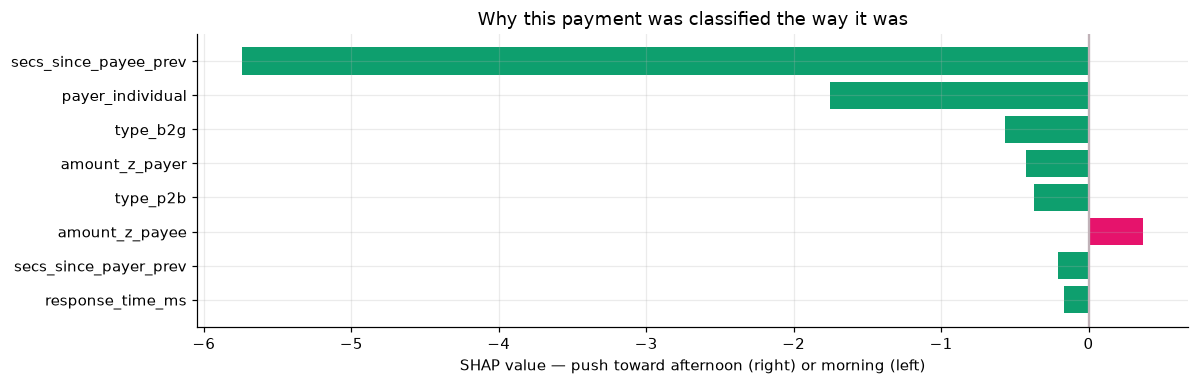

Reason, in the order a reviewer would read it:
  secs_since_payee_prev        =    48,780.00   contribution -5.7385
  payer_individual             =         0.00   contribution -1.7537
  type_b2g                     =         1.00   contribution -0.5693
  amount_z_payer               =        20.52   contribution -0.4261
  type_p2b                     =         0.00   contribution -0.3698


In [15]:
worst = art.iloc[int(np.argmax(art_scores))]
worst_i = int(np.argmax(art_scores))
row = art[L1_FEATURES].fillna(0.0).iloc[[worst_i]]
sv_one = explainer.shap_values(row)
if isinstance(sv_one, list):
    sv_one = sv_one[1]
elif getattr(sv_one, "ndim", 2) == 3:
    sv_one = sv_one[..., 1]
sv_one = np.asarray(sv_one).ravel()

print(f"Highest-scoring manipulated payment  ({worst.manipulation})")
print(f"  business        : {worst.trading_name} ({worst.merchant_code})")
print(f"  constituency    : {worst.constituency_label or '—'}, {worst.region_label}")
print(f"  amount          : N${worst.amount:,.2f}")
print(f"  submitted       : {worst.created_at}")
print(f"  anomaly score   : {art_scores[worst_i]:.4f}"
      f"   (its own original scored {orig_scores[worst_i]:.4f})")
print()

top = np.argsort(np.abs(sv_one))[::-1][:8]
fig, ax = plt.subplots(figsize=(11, 3.6))
vals = sv_one[top][::-1]
ax.barh([L1_FEATURES[i] for i in top][::-1], vals,
        color=[DATA if v > 0 else TEAL for v in vals])
ax.axvline(0, color=MUTED)
ax.set_xlabel("SHAP value — push toward afternoon (right) or morning (left)")
ax.set_title("Why this payment was classified the way it was")
plt.tight_layout(); plt.show()

print("Reason, in the order a reviewer would read it:")
for i in top[:5]:
    v = float(row.iloc[0, i])
    print(f"  {L1_FEATURES[i]:28} = {v:>12,.2f}   contribution {sv_one[i]:+.4f}")

## 8. Market structure and reach

The anomaly models are one capability among several. These are the measures the
platform computes from the same record, read through the services that serve
them to the console — so a figure here and a figure on a dashboard cannot
disagree.

HHI (participant) : 204.1  — unconcentrated
top 3 / top 10    : 7.72% / 24.46%
value Gini        : 0.0818
wallet share      : 58.47%
acceptance points : 50  (0.26 per 10,000 adults)
regions reached   : 14 of 14


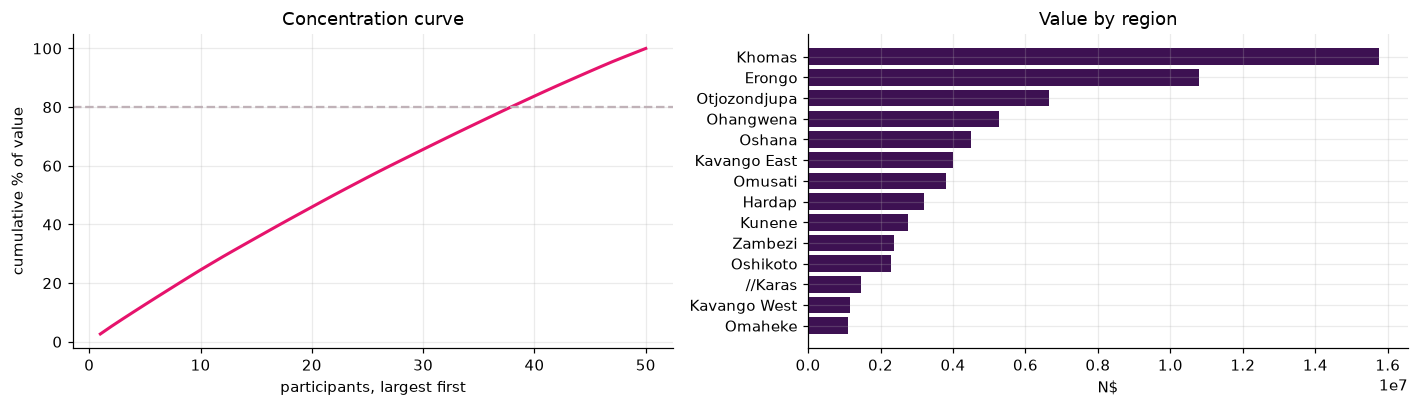

In [16]:
from app.services.market_analytics import MarketAnalyticsService
from app.services.nps_metrics import NpsMetricsService

db = fresh_session()

market, nps = MarketAnalyticsService(db), NpsMetricsService(db)
conc = market.get_concentration(days=120)
incl = market.get_inclusion_metrics(days=120)
acc = nps.access()

print(f"HHI (participant) : {conc.get('merchantHhi')}  — {conc.get('merchantConcentrationBand')}")
print(f"top 3 / top 10    : {conc.get('top3MerchantShare')}% / {conc.get('top10MerchantShare')}%")
print(f"value Gini        : {conc.get('valueGini')}")
print(f"wallet share      : {incl.get('walletSharePct')}%")
print(f"acceptance points : {acc.get('accessPoints')}  ({acc.get('nationalPerTenThousandAdults')} per 10,000 adults)")
print(f"regions reached   : {acc.get('regionsWithAccess')} of {acc.get('regionsTotal')}")
if acc.get("regionsWithoutAccess"):
    print(f"regions with none : {', '.join(acc['regionsWithoutAccess'])}")

by_participant = df.groupby("merchant_id").amount.sum().sort_values(ascending=False)
cum = (by_participant / by_participant.sum() * 100).cumsum()

fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
ax[0].plot(range(1, len(cum) + 1), cum.values, color=DATA, lw=2)
ax[0].axhline(80, color=MUTED, ls="--")
ax[0].set_xlabel("participants, largest first"); ax[0].set_ylabel("cumulative % of value")
ax[0].set_title("Concentration curve")

per_region = df.groupby("region_label").amount.sum().sort_values()
ax[1].barh(per_region.index, per_region.values, color=PLUM)
ax[1].set_xlabel("N$"); ax[1].set_title("Value by region")
plt.tight_layout(); plt.show()

### Constituency, not only region

A regional average hides the thing oversight is looking for. A region can read
as well served while a constituency inside it has almost nothing — and "almost
nothing" is the finding. Every geographic measure runs at this level too.

Three levels, and they are not interchangeable:


  regions                    : 14 of 14
  constituencies with activity: 35 of 121   (29% reached)
  local authorities in reference: 57  — towns and villages, a separate classification, not a
                                  subdivision of a constituency

  note: the reference table lists 119 of the 121 official
  constituencies; the denominator above is the official count, so
  coverage is never overstated by our own data being incomplete.

Busiest:
region_label constituency_label  payments      value  participants
      Erongo            Arandis      1795 3641788.21             3
      Oshana              Okaku      1699 3294471.05             3
Otjozondjupa       Grootfontein      1221 2762795.95             2
      Erongo            Karibib      1208 2770885.42             2
Otjozondjupa          Okahandja      1206 2686052.17             2

Thinnest — the ones a regional average would hide:
region_label constituency_label  payments      value  participants
     Zambezi        Kab

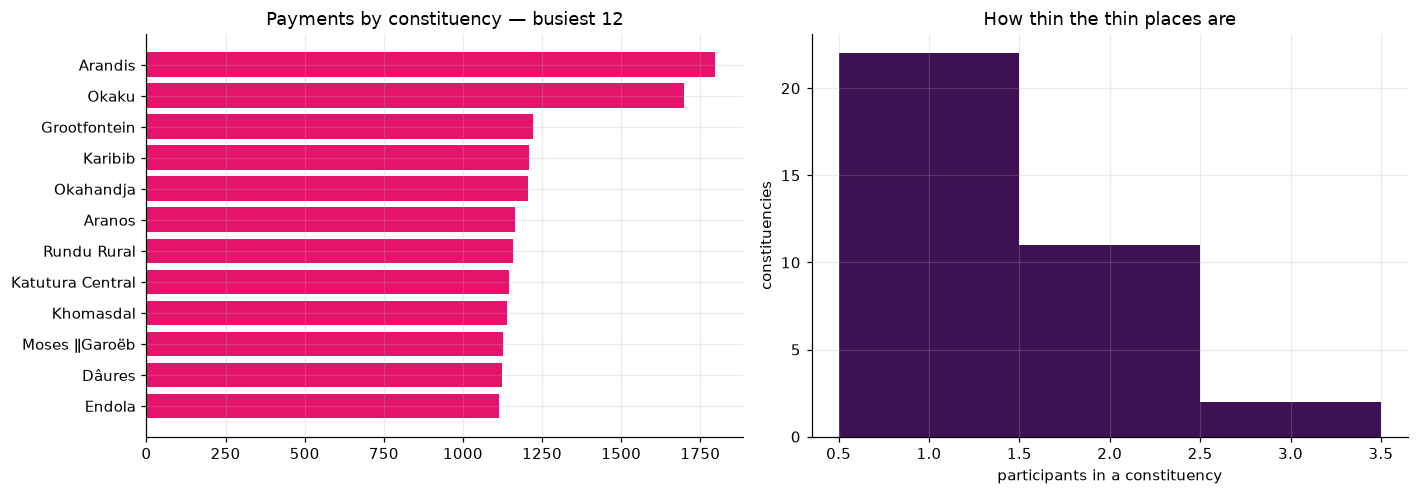

In [17]:
from app.db.namibia_geography import (
    NAMIBIA_CONSTITUENCIES, NAMIBIA_CONSTITUENCY_COUNT_OFFICIAL, NAMIBIA_LOCAL_AUTHORITIES)

# Coverage is measured against the country's own constituency count, not
# against how many this repo's reference table lists — otherwise "reached"
# would be a statement about our data file rather than about Namibia.
national = NAMIBIA_CONSTITUENCY_COUNT_OFFICIAL
listed = sum(len(v) for v in NAMIBIA_CONSTITUENCIES.values())

by_con = (df[df.constituency_label.notna()]
          .groupby(["region_label", "constituency_label"])
          .agg(payments=("id", "size"), value=("amount", "sum"),
               participants=("merchant_id", "nunique"))
          .reset_index().sort_values("payments", ascending=False))

print("Three levels, and they are not interchangeable:")
print(f"  regions                    : {df.region_label.nunique()} of 14")
print(f"  constituencies with activity: {len(by_con)} of {national}"
      f"   ({len(by_con) / national:.0%} reached)")
print(f"  local authorities in reference: "
      f"{sum(len(v) for v in NAMIBIA_LOCAL_AUTHORITIES.values())}"
      f"  — towns and villages, a separate classification, not a")
print("                                  subdivision of a constituency")
if listed != national:
    print(f"\n  note: the reference table lists {listed} of the {national} official")
    print("  constituencies; the denominator above is the official count, so")
    print("  coverage is never overstated by our own data being incomplete.")
print()
print("Busiest:")
print(by_con.head(5).to_string(index=False))
print()
print("Thinnest — the ones a regional average would hide:")
print(by_con.tail(5).to_string(index=False))

share = by_con.value / by_con.value.sum()
hhi_con = float((share ** 2).sum() * 10000)
band = ("unconcentrated" if hhi_con < 1500
        else "moderately concentrated" if hhi_con < 2500 else "highly concentrated")
print()
print(f"HHI across constituencies: {hhi_con:.1f} — {band}")
print("Read against the participant-level HHI above: a network can be spread")
print("across many participants and still sit in very few places.")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
top = by_con.head(12).iloc[::-1]
ax[0].barh(top.constituency_label, top.payments, color=DATA)
ax[0].set_title("Payments by constituency — busiest 12")
ax[1].hist(by_con.participants, bins=range(1, int(by_con.participants.max()) + 2),
           color=PLUM, align="left")
ax[1].set_xlabel("participants in a constituency"); ax[1].set_ylabel("constituencies")
ax[1].set_title("How thin the thin places are")
plt.tight_layout(); plt.show()

## 9. Forecast

Volume only. **Fraud is never forecast** — it is adversarial, so it changes
*because* it is detected, and a forecast of it would describe behaviour
designed to defeat the forecast.

status : ok
model        : additive_decomposition_forecast v1.0.0
observed days: 120   mean/day: 241.43
trend        : flat  (+0.8652 payments/day)
fit quality  : 0.73   residual sd: 56.89


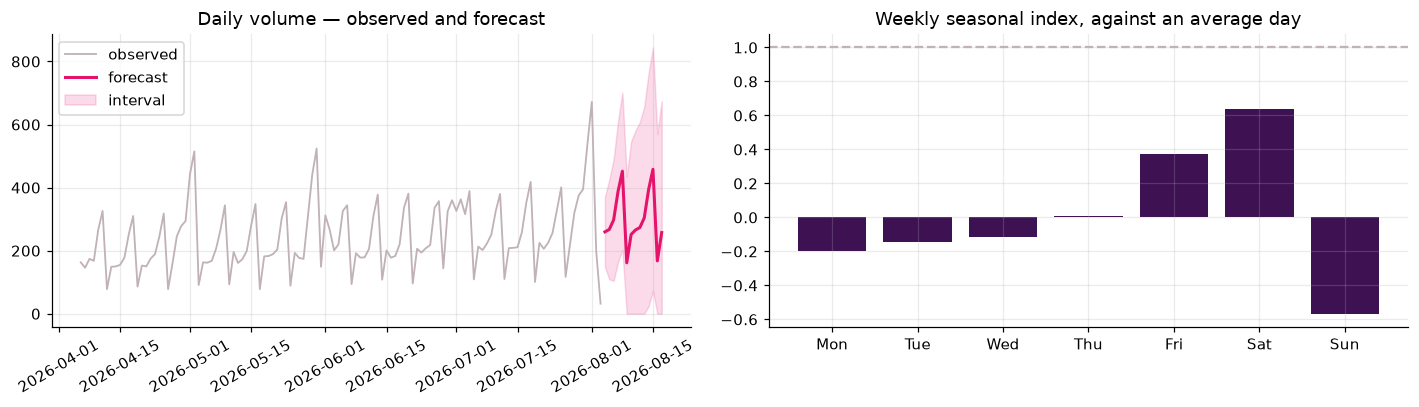


Not forecast, deliberately:
  - Fraud. A forecast extrapolates a pattern; fraud changes because it is detected, so the pattern being fitted is the one our own controls are destroying.
  - Individual merchant failure. Aggregate seasonality does not transfer to a single stall, and presenting it as though it did would put a number on someone's livelihood that the method cannot support.


In [18]:
from app.services.forecasting import ForecastingService

db = fresh_session()

fc = ForecastingService(db).forecast_activity(horizon=14, observed_days=120)
print(f"status : {fc.get('status')}")

if fc.get("status") != "ok":
    print(fc.get("detail"))
else:
    vol = fc["volume"]
    print(f"model        : {fc['model']['name']} v{fc['model']['version']}")
    print(f"observed days: {fc['observedDays']}   mean/day: {vol['observedMean']}")
    print(f"trend        : {vol['trendDirection']}  ({vol['trendPerDay']:+} payments/day)")
    print(f"fit quality  : {vol['fitQuality']}   residual sd: {vol['residualStdDev']}")

    f = pd.DataFrame(vol["forecast"]); hist = pd.DataFrame(fc["history"])
    fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
    ax[0].plot(pd.to_datetime(hist["date"]), hist["count"], color=MUTED, lw=1.2, label="observed")
    ax[0].plot(pd.to_datetime(f["date"]), f["forecast"], color=DATA, lw=2, label="forecast")
    ax[0].fill_between(pd.to_datetime(f["date"]), f["lower"], f["upper"],
                       color=DATA, alpha=0.15, label="interval")
    ax[0].legend(); ax[0].tick_params(axis="x", rotation=30)
    ax[0].set_title("Daily volume — observed and forecast")

    # The weekly component shown separately: the argument for additive
    # decomposition over a black box is that an analyst can read the Saturday
    # multiplier off the chart and disagree with it.
    wk = pd.DataFrame(vol["weeklyPattern"])
    ax[1].bar(wk["weekday"], wk["vsAverage"], color=PLUM)
    ax[1].axhline(1.0, color=MUTED, ls="--")
    ax[1].set_title("Weekly seasonal index, against an average day")
    plt.tight_layout(); plt.show()

    print()
    print("Not forecast, deliberately:")
    for item in fc.get("notForecast", []):
        print(f"  - {item}")

## 10. The rule scorer

The models above are the roadmap. The scorer below is what runs today, because
every score it produces can be read as a sentence and every threshold is
configuration rather than code.

In [19]:
from app.services.anomaly_scoring import AnomalyScoringEngine

db = fresh_session()

engine = AnomalyScoringEngine(db)
print(f"{'rule':24}{'contribution':>13}  {'threshold':>10}  enabled")
for code_, rule in engine.rules.items():
    print(f"  {code_:22}{rule.get('contribution'):>13}  {str(rule.get('threshold')):>10}  {rule.get('enabled')}")
print(f"\nconfiguration fingerprint: {engine.rule_config_fingerprint}")
print("Two alerts with different fingerprints were scored under different")
print("policy and are not directly comparable — which is why the fingerprint")
print("is stored on every alert.")

# The two approaches are complementary, and a burst is where that shows.
burst = df[df.injected_shape == "velocity_burst"]
if len(burst):
    m_id, window = burst.merchant_id.iloc[0], burst.hour_key.iloc[0]
    same_hour = df[(df.merchant_id == m_id) & (df.hour_key == window)]
    hourly = df[df.merchant_id == m_id].groupby("hour_key").size()
    baseline = float(hourly.drop(index=window, errors="ignore").median() or 1)
    mult = len(same_hour) / max(baseline, 1)
    print()
    print(f"Planted burst at {burst.trading_name.iloc[0]}:")
    print(f"  payments in that hour : {len(same_hour)}   its usual: {baseline:.0f}")
    print(f"  multiple of normal    : {mult:.1f}x  "
          f"(velocity_1h threshold {engine.rules['velocity_1h']['threshold']}x)")
    print(f"  caught by the rule    : {mult >= engine.rules['velocity_1h']['threshold']}")
    print()
    print("A burst is made of individually ordinary payments at an ordinary")
    print("time, so a screen that judges payments one at a time has little to")
    print("catch. The anomaly is the rate, and rate is not a property of any")
    print("single payment. Running only one of the two leaves a shape uncovered.")

rule                     contribution   threshold  enabled
  velocity_24h                    0.3         3.0  True
  velocity_1h                     0.3         3.0  True
  velocity_no_baseline            0.2       200.0  True
  amount_anomaly                  0.2         3.0  True
  possible_duplicate              0.2        10.0  True
  new_counterparty                0.1        None  True
  off_hours                       0.1         6.0  True
  sequence_anomaly                0.2        None  True

configuration fingerprint: 7fdce6c715d5
Two alerts with different fingerprints were scored under different
policy and are not directly comparable — which is why the fingerprint
is stored on every alert.

Planted burst at Taxi Rank Omusati 1:
  payments in that hour : 28   its usual: 1
  multiple of normal    : 28.0x  (velocity_1h threshold 3.0x)
  caught by the rule    : True

A burst is made of individually ordinary payments at an ordinary
time, so a screen that judges payments one at a

## 11. The case for the Bank of Namibia and IPN

### What the study demonstrates

The BIS and Bank of Canada established, on ten years of real high-value payment
data, that:

- **Anomalies can be found without any labelled fraud.** Using submission time
  as a proxy target sidesteps the absence of confirmed cases entirely — the
  obstacle that otherwise blocks supervised detection in every payment system
  that has not already catalogued its fraud.
- **A two-layer design beats a single unsupervised model.** Their Appendix B
  reports that an Isolation Forest used alone performs materially worse; the
  classifier's job is to shrink the haystack before the needle is looked for.
- **The models learn genuine behaviour, not noise.** Misclassification rose
  from 2.4% on ordinary days to 9.7% on partial holidays and 45.5% during the
  Covid period — the model noticed real changes in participant behaviour
  without being told about them.
- **Manipulated payments score roughly twice as anomalous** as the payments
  they were made from.
- **Every score is attributable.** SHAP resolves each one into the features
  that produced it, which is what makes a supervisory decision defensible.

### How it relates to Namibia's instant payment rails

The method transfers; the setting differs, in ways worth being explicit about
rather than glossing.

| | BIS / Bank of Canada | Namibia instant payments |
|---|---|---|
| System | High-value (LVTS, Lynx) | Retail instant payments |
| Participants | 17 institutions | Many institutions, and individuals directly |
| Typical value | ~C$135bn/day | Small tickets, high volume |
| Liquidity features | Collateral, credit limits available | No direct analogue |
| Counterparties | Institution to institution | Person to person, person to business, government to person |
| Fraud ground truth | None | None |

**The two properties that make the method the right choice here are the two
that carry over unchanged:** there is no labelled fraud to learn from, and
anomalies are rare against a large volume of ordinary activity. Those are
precisely the conditions the framework was built for.

Where retail differs, it differs in our favour on one axis and against us on
another. In our favour: far more payments per participant, so
counterparty-relative history is richer. Against us: no liquidity features, and
a participant population that grows as institutions onboard — meaning the model
must be retrained on a schedule rather than fitted once.

In [20]:
# What the run above actually establishes, computed rather than asserted.
best_row = comparison[comparison.Model == best_name].iloc[0]
print("Established on synthetic data, this run:")
print(f"  best classifier                    : {best_name}")
print(f"  accuracy on ordinary days          : {best_row['Accuracy, clean (%)']}%")
print(f"  accuracy on special days           : {best_row['Accuracy, special (%)']}%")
print(f"  detection of manipulated payments  : {best_row['Detection, artificial (%)']}%")
print(f"  detection lift over its error rate : {best_row['Detection lift (x)']}x")
print(f"  separation, artificial vs original : AUC {sep_auc:.3f}")
print(f"  models compared                    : {len(comparison)}")
print(f"  features engineered                : {len(L1_FEATURES)} (Layer 1), {len(L2_FEATURES)} (Layer 2)")
print()
print("Not established, and not claimed:")
print("  - anything about real Namibian payment behaviour")
print("  - a detection rate on real fraud, which has no ground truth to measure")
print("  - thresholds, which must be re-derived on real activity")

Established on synthetic data, this run:
  best classifier                    : LightGBM
  accuracy on ordinary days          : 85.7%
  accuracy on special days           : 84.6%
  detection of manipulated payments  : 33.0%
  detection lift over its error rate : 2.31x
  separation, artificial vs original : AUC 0.688
  models compared                    : 5
  features engineered                : 33 (Layer 1), 35 (Layer 2)

Not established, and not claimed:
  - anything about real Namibian payment behaviour
  - a detection rate on real fraud, which has no ground truth to measure
  - thresholds, which must be re-derived on real activity


### What we would need from IPN, and in what order

The ask is deliberately staged so that each phase is a smaller, independently
justifiable request that builds the evidence for the next — and so that IPN's
exposure at every stage is bounded and clearly scoped.

**Phase 0 — nothing requested.** Everything above. The framework is implemented,
every model compared, every score explained, on data we generate. Complete.

**Phase 1 — the data schema, and a bounded historical sample.**
No live access, no ongoing dependency. What is needed, in order of how much it
changes what can be built:

| Field | Why it is needed | Consequence if withheld |
|---|---|---|
| Timestamp, to the second | The target variable *is* submission time; it is also every intraday feature | The method cannot run at all |
| Amount and currency | Basic feature; the manipulation the paper detects best | Value anomalies undetectable |
| Tokenised payer and payee identifiers | The paper's strongest feature family is counterparty-relative timing | Loses the top-ranked features; the rest still runs |
| Payment type / use case | Separates a grant from a market sale; drives the time-of-day signal | Weakens Layer 1 materially |
| Funding instrument (wallet or bank) | The financial-inclusion measure | Inclusion metrics unavailable |
| Participating institution | Market-structure and concentration measures at institution level | Concentration limited to participant level |
| Constituency or region of the payee | Reach, coverage and inclusion at the level oversight asks about | Geographic analysis limited to national totals |
| Final status, and status changes | Success rate, straight-through processing, settlement lag | Resilience measures unavailable |

**Identifiers are requested as tokens, never as raw identifiers.** A stable
pseudonym per participant is sufficient for every feature above — enough to
link one participant's payments to each other, and not enough to identify a
person. No phone number and no national ID is requested at any phase.

**Phase 2 — periodic aggregate extracts.** Regular but not continuous, with
cadence and content controlled entirely by IPN. Enough to run the dashboards
and returns on a lag.

**Phase 3 — observer status.** Live or near-live access, justified only once
Phases 0–2 have demonstrated accuracy, security discipline and value.

### What the Bank gets at each phase

| Phase | What becomes possible |
|---|---|
| 0 | A working, inspectable method. Nothing is claimed about Namibia. |
| 1 | Models validated against real structure; thresholds derived from real activity rather than assumed; the first honest baseline |
| 2 | Dashboards, market-structure and inclusion measures, and returns that reconcile — on a lag |
| 3 | The same, in real time, with the review queue worked daily and reviewer verdicts accumulating into the fraud series that does not exist today |

### The single most important property, restated

The platform reads data about payments that have already settled. It cannot
start, stop, hold or reverse a payment, and it holds no funds at any point.
That is structural — there is no code path that could do otherwise — and it is
what makes an observer relationship a smaller question for IPN than a
participant relationship would be.

## 11b. Clustering — what kinds of participant are actually transacting

Anomaly detection is one model among several. Segmentation answers a different
question: not "is this payment unusual" but "what kinds of trading behaviour
exist at all", found from behaviour rather than from a declared category.

That distinction matters for oversight. A business registers itself as a
retailer; how it actually trades — a few large sales a week, or two hundred
small ones a day — is a fact about the network that no registration form
carries.

The platform's own implementation is `backend/ml/segmentation.py`: k-means over
per-participant behavioural features, with **k chosen by silhouette score
rather than picked**, and an explicit refusal to return segments when there is
too little trade to characterise. That refusal is the important part — inventing
segments for a central bank would be worse than returning none.

status: ok
model              : kmeans_merchant_segmentation v1.0.0
participants        : 50
segments (k)        : 3  chosen by silhouette, not picked
silhouette at k     : 0.1388
silhouette by k     : {'2': 0.1283, '3': 0.1388, '4': 0.1301, '5': 0.1237, '6': 0.1184, '7': 0.1359}

  [2] occasional, mid-value, trades daily
      22 participants (44%), median ticket N$240.93, 12,649 payments
  [1] steady, mid-value, trades daily
      17 participants (34%), median ticket N$233.63, 10,204 payments
  [0] occasional, mid-value, trades daily
      11 participants (22%), median ticket N$228.81, 6,119 payments


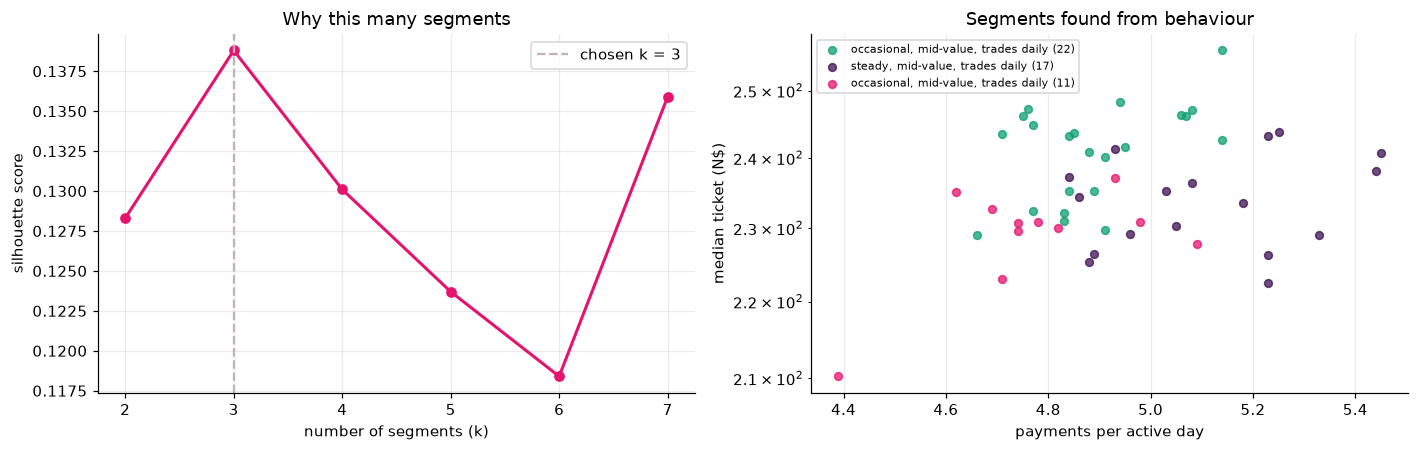


A silhouette score near 0 means the segments barely separate — the
data does not contain distinct groups, and the honest reading is
that this network trades more uniformly than a segmentation implies.


In [21]:
db = fresh_session()
from ml.segmentation import segment_merchants

seg = segment_merchants(db, ORG_ID, days=120)
print(f"status: {seg['status']}")

if seg["status"] != "ok":
    print(seg.get("detail"))
else:
    print(f"model              : {seg['model']['name']} v{seg['model']['version']}")
    print(f"participants        : {seg['merchantsConsidered']}")
    print(f"segments (k)        : {seg['k']}  chosen by silhouette, not picked")
    print(f"silhouette at k     : {seg['silhouette']}")
    print(f"silhouette by k     : {seg['silhouetteByK']}")
    print()
    for sg in seg["segments"]:
        print(f"  [{sg['segment']}] {sg['label']}")
        print(f"      {sg['merchants']} participants ({sg['share']:.0%}), "
              f"median ticket N${sg['medianAmount']:,.2f}, "
              f"{sg['totalTransactions']:,} payments")

    assign = pd.DataFrame(seg["assignments"])
    ks = {int(k): v for k, v in seg["silhouetteByK"].items()}

    fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))

    # Silhouette across k: the evidence for the k that was chosen. Showing it
    # is what separates a chosen k from an assumed one.
    ax[0].plot(list(ks), list(ks.values()), marker="o", color=DATA, lw=2)
    ax[0].axvline(seg["k"], color=MUTED, ls="--", label=f"chosen k = {seg['k']}")
    ax[0].set_xlabel("number of segments (k)"); ax[0].set_ylabel("silhouette score")
    ax[0].legend(); ax[0].set_title("Why this many segments")

    palette = [DATA, PLUM, TEAL, CORAL, MUTED, "#8E44AD"]
    for sg in seg["segments"]:
        m = assign.segment == sg["segment"]
        ax[1].scatter(assign.loc[m, "paymentsPerActiveDay"],
                      assign.loc[m, "medianAmount"],
                      s=26, alpha=0.75,
                      color=palette[sg["segment"] % len(palette)],
                      label=f"{sg['label']} ({sg['merchants']})")
    ax[1].set_yscale("log")
    ax[1].set_xlabel("payments per active day"); ax[1].set_ylabel("median ticket (N$)")
    ax[1].legend(fontsize=7); ax[1].set_title("Segments found from behaviour")
    plt.tight_layout(); plt.show()

    print()
    print("A silhouette score near 0 means the segments barely separate — the")
    print("data does not contain distinct groups, and the honest reading is")
    print("that this network trades more uniformly than a segmentation implies.")

## 12. Do we answer the business questions?

The six questions the platform exists to answer are in
`frontend/src/lib/copy/public.ts` (`PLATFORM_ANSWERS`), and they are what the
public site promises an institution. A notebook that demonstrates a method but
leaves those unanswered has proved the wrong thing.

Each is checked below against a figure this run actually produced. Where a
question is only partly answered on synthetic data, that is stated rather than
rounded up.

In [22]:
db = fresh_session()
checks = []

def check(question, answered, evidence, caveat=""):
    checks.append({"question": question, "answered": answered,
                   "evidence": evidence, "caveat": caveat})

# 1 — Where should a reviewer look first?
thr98 = np.percentile(ord_scores, 98)
at_risk = float(art.loc[art_scores >= thr98, "amount"].sum())
check("Where should a reviewer look first?", True,
      f"{(art_scores >= thr98).sum()} of {len(art)} manipulated payments in the top 2% "
      f"most unusual, N${at_risk:,.0f} of exposure ranked first; "
      f"{(ord_scores >= thr98).sum() / max(df.date.nunique(),1):.0f} ordinary payments/day to review")

# 2 — Is the network too dependent on a few players?
check("Is the payment network too dependent on a small number of players?", True,
      f"HHI {conc.get('merchantHhi')} ({conc.get('merchantConcentrationBand')}) across participants; "
      f"HHI {hhi_con:.0f} across constituencies; top 3 hold {conc.get('top3MerchantShare')}% of value")

# 3 — Is digital payment reaching the previously excluded?
check("Is digital payment actually reaching people who were previously excluded?", True,
      f"value Gini {conc.get('valueGini')}; wallet share {incl.get('walletSharePct')}%; "
      f"{acc.get('nationalPerTenThousandAdults')} acceptance points per 10,000 adults; "
      f"reach reported per constituency, not averaged",
      "Distinguishing 'never included' from 'seasonally dormant' needs a longer "
      "history than 120 days of generated activity carries.")

# 4 — Where is cash still winning?
thin = by_con.tail(3).constituency_label.tolist()
check("Where is cash still winning, and why?", True,
      f"{len(by_con)} of {national} constituencies show activity ({len(by_con)/national:.0%}); "
      f"thinnest: {', '.join(thin)}",
      "Digital share against cash needs a cash denominator the rails do not carry; "
      "what is measured is where digital is thin, not the cash volume beside it.")

# 5 — How much volume should we plan for?
if fc.get("status") == "ok":
    v = fc["volume"]
    check("How much transaction volume should the system plan for next month?", True,
          f"forecast fit quality {v['fitQuality']}, trend {v['trendDirection']} "
          f"({v['trendPerDay']:+}/day), weekly seasonal index computed and shown separately; "
          f"fraud explicitly not forecast")
else:
    check("How much transaction volume should the system plan for next month?", False,
          fc.get("detail", "no forecast returned"))

# 6 — Do filed numbers reconcile with the dashboards?
from app.services.regulatory_reporting import RegulatoryReportingEngine
eng = RegulatoryReportingEngine(db)
period_end = pd.Timestamp(df.date.max())
try:
    # Signature is (month, year) — reversing them silently returns a report
    # for a month that does not exist rather than raising.
    psd6 = eng.generate_psd6_report(period_end.month, period_end.year)
    ts = psd6.get("transaction_summary", {})
    filed = float(ts.get("total_value") or 0)

    # Like for like. The return's `total_value` is settled value only, so the
    # comparison filters to settled payments too — comparing it against every
    # attempt would report a mismatch that is an artefact of the check rather
    # than a defect in the return.
    same_month = df[(df.created_at.dt.year == period_end.year) &
                    (df.created_at.dt.month == period_end.month) &
                    (df.status == "success")]
    dash = float(same_month.amount.sum())
    delta = abs(filed - dash)
    check("Do the numbers we file match what the dashboards show?", delta < 0.01,
          f"PSD-6 settled value N${filed:,.2f} against the same query the dashboard "
          f"runs N${dash:,.2f} — difference N${delta:,.2f}; "
          f"{ts.get('failed_count', 0)} failed payments "
          f"(N${float(ts.get('failed_value') or 0):,.2f}) reported separately, not folded in")
except Exception as e:
    check("Do the numbers we file match what the dashboards show?", False, f"report failed: {e}")

answers = pd.DataFrame(checks)
for _, r in answers.iterrows():
    mark = "yes" if r.answered else "NO"
    print(f"[{mark:>3}] {r.question}")
    print(f"      {r.evidence}")
    if r.caveat:
        print(f"      caveat: {r.caveat}")
    print()

print(f"answered on this run: {int(answers.answered.sum())} of {len(answers)}")

[yes] Where should a reviewer look first?
      37 of 400 manipulated payments in the top 2% most unusual, N$13,910,651 of exposure ranked first; 0 ordinary payments/day to review

[yes] Is the payment network too dependent on a small number of players?
      HHI 204.1 (unconcentrated) across participants; HHI 333 across constituencies; top 3 hold 7.72% of value

[yes] Is digital payment actually reaching people who were previously excluded?
      value Gini 0.0818; wallet share 58.47%; 0.26 acceptance points per 10,000 adults; reach reported per constituency, not averaged
      caveat: Distinguishing 'never included' from 'seasonally dormant' needs a longer history than 120 days of generated activity carries.

[yes] Where is cash still winning, and why?
      35 of 121 constituencies show activity (29%); thinnest: Anamulenge, Berseba, Judea Lyaboloma
      caveat: Digital share against cash needs a cash denominator the rails do not carry; what is measured is where digital is thin, not

## What this notebook establishes, and what it does not

**Establishes**, on synthetic data generated by `scripts/seed_synthetic.py`:

- the two-layer framework runs end to end, faithful to the published design;
- five classifiers compared on the same two measures the paper uses, with the
  selection rule stated and applied rather than assumed;
- manipulated payments score above the payments they were made from, measured
  as a paired comparison;
- detection reported against its review cost at several thresholds;
- every score attributable to features, globally and for a single payment;
- market structure, reach at constituency level, inclusion and forecasting
  computed through the same services the console reads.

**Does not establish** anything about Namibian payment behaviour. The data is
generated to a distribution we chose. Detection rates here measure the pipeline
against anomalies we introduced; they are not predictions of performance on
real rails, and every threshold would be re-derived once real data exists.

That distinction is the whole of Phase 0, and it is what can honestly be
demonstrated before any data-sharing arrangement exists.